In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
# Load fit parameters and extract numeric power
df = pd.read_csv("/Users/snip/Documents/MEOP/power_dependence_plots/fit_parameters_all_files.csv")

# Extract numeric power (e.g., "3W" → 3)
df["power_W"] = df["power"].str.replace("W", "").astype(int)

# Split by cell
df_C8 = df[df["cell"] == "C8"].copy()
df_C9 = df[df["cell"] == "C9"].copy()

print(f"Total files: {len(df)}")
print(f"  C8: {len(df_C8)} files, powers: {sorted(df_C8['power_W'].unique())} W")
print(f"  C9: {len(df_C9)} files, powers: {sorted(df_C9['power_W'].unique())} W")

# -----------------------------------------------------------------------
# For each power level with N repeated measurements:
#
#   σ_fit_mean = (1/N) * sqrt( Σ σ_fit_i² )   ← quadrature mean of fit errors
#   σ_rms      = std of the N measured values   ← run-to-run spread
#   σ_total    = sqrt( σ_fit_mean² + σ_rms² )
# -----------------------------------------------------------------------

def quad_mean_err(x):
    """Quadrature mean: sqrt(sum(xi²)) / N"""
    return np.sqrt((x**2).sum()) / len(x)

def compute_avg(grp_df, param):
    """Return per-power DataFrame with mean, σ_fit_mean, σ_rms, σ_total."""
    return grp_df.groupby("power_W").apply(
        lambda g: pd.Series({
            f"{param}_mean":         g[param].mean(),
            f"{param}_fit_mean":     quad_mean_err(g[f"{param}_err"]),
            f"{param}_rms":          g[param].std(ddof=1),
            f"{param}_total":        np.sqrt(
                                         quad_mean_err(g[f"{param}_err"])**2
                                         + g[param].std(ddof=1)**2
                                     ),
            "n": len(g),
        })
    ).reset_index()

# Build averaged tables for C8 and C9
for cell_label, cell_df in [("C8", df_C8), ("C9", df_C9)]:
    ppl    = compute_avg(cell_df, "P_plateau")
    tau_b  = compute_avg(cell_df, "tau_b")
    tau_d  = compute_avg(cell_df, "tau")          # tau_decay
    avg = ppl.merge(tau_b.drop(columns="n"), on="power_W") \
             .merge(tau_d.drop(columns="n"), on="power_W")
    if cell_label == "C8":
        df_C8_avg = avg
    else:
        df_C9_avg = avg

print("\nC8 averaged:")
cols = ["power_W", "P_plateau_mean", "P_plateau_total",
        "tau_b_mean", "tau_b_total",
        "tau_mean", "tau_total", "n"]
print(df_C8_avg[cols].to_string(index=False))
print("\nC9 averaged:")
print(df_C9_avg[cols].to_string(index=False))

Total files: 36
  C8: 18 files, powers: [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)] W
  C9: 18 files, powers: [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)] W

C8 averaged:
 power_W  P_plateau_mean  P_plateau_total  tau_b_mean  tau_b_total   tau_mean  tau_total   n
       3       53.411621         0.425186   16.923275     0.297980 109.690486   0.559205 3.0
       4       55.777814         0.057128   15.576155     0.780958 117.695845   0.955356 3.0
       5       55.273722         0.094340   12.133667     0.580032 102.380555   0.399565 3.0
       6       56.415134         0.042740   12.553671     0.464261 101.343244   0.388960 3.0
       7       55.862203         0.079796   11.218777     0.499893  90.273128   0.738326 3.0
       8       55.427056         0.145405   16.303132     1.307331 100.368679   0.627677 3.0

C9 averaged:
 power_W  P_plateau_mean  P_plateau_total  tau_b_mean  tau_b_total   tau_mean  tau_total   n
  

/var/folders/gd/9mz33tj93gxcvrr1gtyl314w0000gn/T/ipykernel_43671/678949439.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return grp_df.groupby("power_W").apply(
/var/folders/gd/9mz33tj93gxcvrr1gtyl314w0000gn/T/ipykernel_43671/678949439.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return grp_df.groupby("power_W").apply(
/var/folders/gd/9mz33tj93gxcvrr1gtyl314w0000gn/T/ipykernel_43671/678949439.py:29: Fu

In [8]:
df_C8_avg

,power_W,P_plateau_mean,P_plateau_fit_mean,P_plateau_rms,P_plateau_total,n,tau_b_mean,tau_b_fit_mean,tau_b_rms,tau_b_total,tau_mean,tau_fit_mean,tau_rms,tau_total
0,3,53.411621,0.027959,0.424266,0.425186,3.0,16.923275,0.220285,0.200666,0.297980,109.690486,0.278490,0.484927,0.559205
1,4,55.777814,0.026812,0.050446,0.057128,3.0,15.576155,0.182396,0.759360,0.780958,117.695845,0.337230,0.893857,0.955356
2,5,55.273722,0.028809,0.089834,0.094340,3.0,12.133667,0.109272,0.569647,0.580032,102.380555,0.303668,0.259688,0.399565
3,6,56.415134,0.024310,0.035153,0.042740,3.0,12.553671,0.113330,0.450216,0.464261,101.343244,0.325703,0.212621,0.388960
4,7,55.862203,0.021025,0.076977,0.079796,3.0,11.218777,0.126046,0.483741,0.499893,90.273128,0.220269,0.704703,0.738326
5,8,55.427056,0.038331,0.140262,0.145405,3.0,16.303132,0.834630,1.006234,1.307331,100.368679,0.271295,0.566018,0.627677


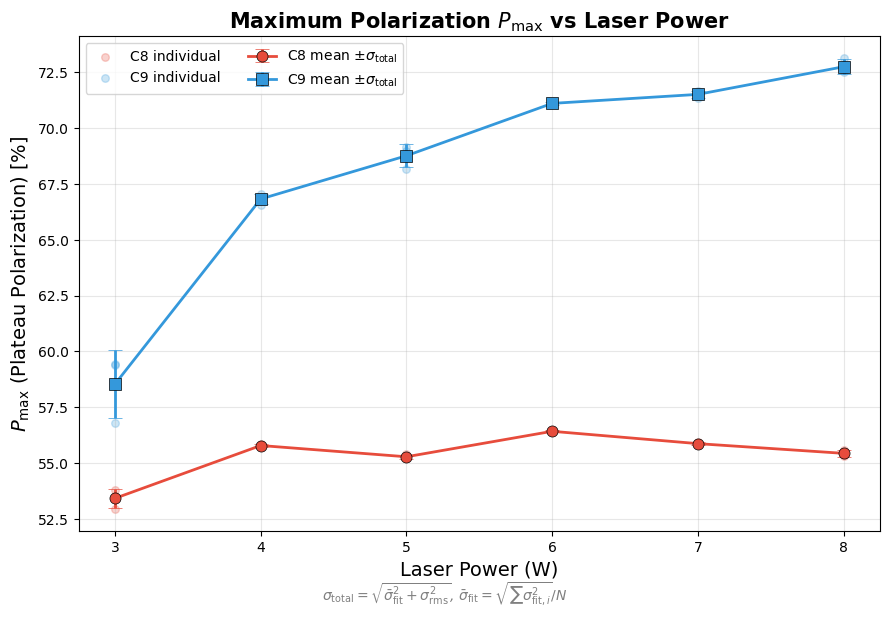

In [9]:
# ============================================================================
# Plot 1: Power vs P_plateau (Maximum Polarization) — C8 and C9 on same plot
# ============================================================================
# σ_total = sqrt( σ_fit_mean² + σ_rms² )
#   σ_fit_mean = sqrt(Σ σ_fit_i²) / N   (quadrature mean of N fit errors)
#   σ_rms      = std of N measured values

fig, ax = plt.subplots(figsize=(9, 6))
dx = 0.

ax.errorbar(df_C8_avg["power_W"] - dx, df_C8_avg["P_plateau_mean"],
            yerr=df_C8_avg["P_plateau_total"],
            fmt='o-', color='#e74c3c', capsize=5, capthick=1.5, elinewidth=2, linewidth=2,
            markersize=8, markeredgecolor='black', markeredgewidth=0.5,
            label=r'C8 mean $\pm\sigma_{\rm total}$')
ax.scatter(df_C8["power_W"] - dx, df_C8["P_plateau"],
           color='#e74c3c', alpha=0.25, s=30, zorder=0, label='C8 individual')

ax.errorbar(df_C9_avg["power_W"] + dx, df_C9_avg["P_plateau_mean"],
            yerr=df_C9_avg["P_plateau_total"],
            fmt='s-', color='#3498db', capsize=5, capthick=1.5, elinewidth=2, linewidth=2,
            markersize=8, markeredgecolor='black', markeredgewidth=0.5,
            label=r'C9 mean $\pm\sigma_{\rm total}$')
ax.scatter(df_C9["power_W"] + dx, df_C9["P_plateau"],
           color='#3498db', alpha=0.25, s=30, zorder=0, label='C9 individual')

ax.set_xlabel("Laser Power (W)", fontsize=14)
ax.set_ylabel("$P_{\\rm max}$ (Plateau Polarization) [%]", fontsize=14)
ax.set_title("Maximum Polarization $P_{\\rm max}$ vs Laser Power", fontsize=15, fontweight='bold')
ax.legend(fontsize=10, ncol=2)
ax.grid(True, alpha=0.3)
ax.set_xticks(sorted(df["power_W"].unique()))
fig.text(0.5, -0.01,
         r"$\sigma_{\rm total}=\sqrt{\bar{\sigma}_{\rm fit}^2+\sigma_{\rm rms}^2}$, "
         r"$\bar{\sigma}_{\rm fit}=\sqrt{\sum\sigma_{{\rm fit},i}^2}/N$",
         ha='center', fontsize=10, style='italic', color='gray')
plt.tight_layout()
plt.savefig("/Users/snip/Documents/MEOP/power_dependence_plots/power_vs_Pmax.png", dpi=150, bbox_inches='tight')
plt.show()

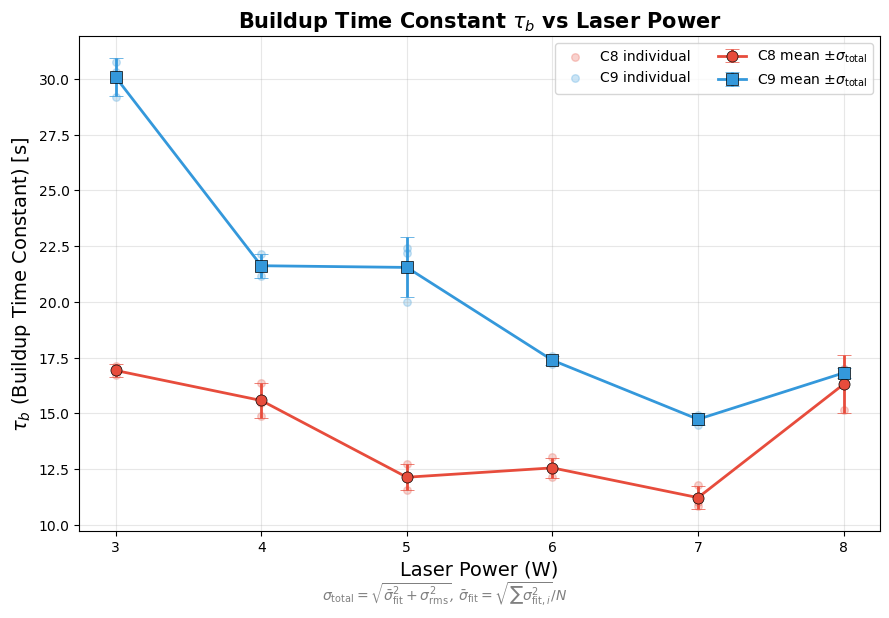

In [10]:
# ============================================================================
# Plot 2: Power vs tau_b (Buildup Time Constant) — C8 and C9 on same plot
# ============================================================================
# σ_total = sqrt( σ_fit_mean² + σ_rms² )

fig, ax = plt.subplots(figsize=(9, 6))
dx = 0.0

ax.errorbar(df_C8_avg["power_W"] - dx, df_C8_avg["tau_b_mean"],
            yerr=df_C8_avg["tau_b_total"],
            fmt='o-', color='#e74c3c', capsize=5, capthick=1.5, elinewidth=2, linewidth=2,
            markersize=8, markeredgecolor='black', markeredgewidth=0.5,
            label=r'C8 mean $\pm\sigma_{\rm total}$')
ax.scatter(df_C8["power_W"] - dx, df_C8["tau_b"],
           color='#e74c3c', alpha=0.25, s=30, zorder=0, label='C8 individual')

ax.errorbar(df_C9_avg["power_W"] + dx, df_C9_avg["tau_b_mean"],
            yerr=df_C9_avg["tau_b_total"],
            fmt='s-', color='#3498db', capsize=5, capthick=1.5, elinewidth=2, linewidth=2,
            markersize=8, markeredgecolor='black', markeredgewidth=0.5,
            label=r'C9 mean $\pm\sigma_{\rm total}$')
ax.scatter(df_C9["power_W"] + dx, df_C9["tau_b"],
           color='#3498db', alpha=0.25, s=30, zorder=0, label='C9 individual')

ax.set_xlabel("Laser Power (W)", fontsize=14)
ax.set_ylabel(r"$\tau_b$ (Buildup Time Constant) [s]", fontsize=14)
ax.set_title(r"Buildup Time Constant $\tau_b$ vs Laser Power", fontsize=15, fontweight='bold')
ax.legend(fontsize=10, ncol=2)
ax.grid(True, alpha=0.3)
ax.set_xticks(sorted(df["power_W"].unique()))
fig.text(0.5, -0.01,
         r"$\sigma_{\rm total}=\sqrt{\bar{\sigma}_{\rm fit}^2+\sigma_{\rm rms}^2}$, "
         r"$\bar{\sigma}_{\rm fit}=\sqrt{\sum\sigma_{{\rm fit},i}^2}/N$",
         ha='center', fontsize=10, style='italic', color='gray')
plt.tight_layout()
plt.savefig("/Users/snip/Documents/MEOP/power_dependence_plots/power_vs_tau_b.png", dpi=150, bbox_inches='tight')
plt.show()

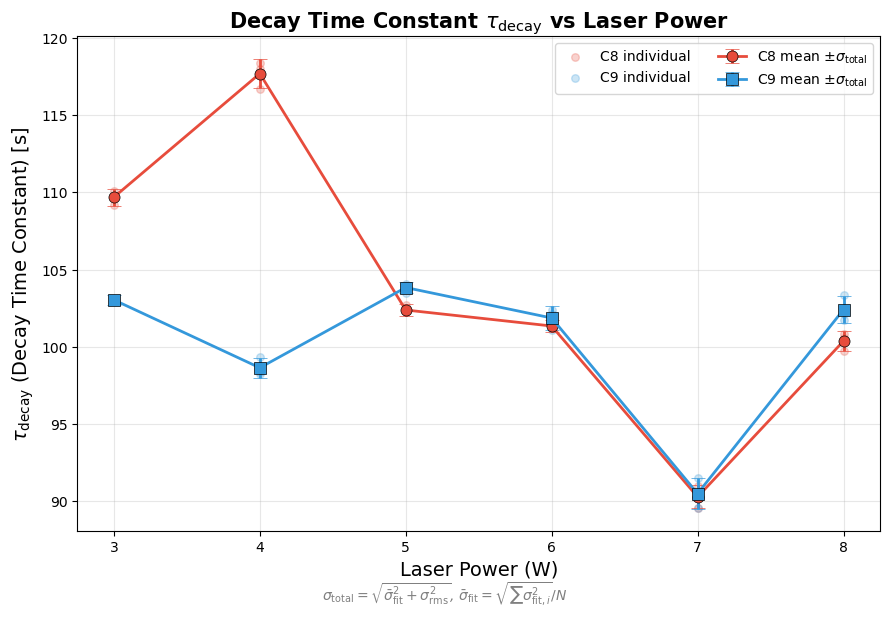

In [11]:
# ============================================================================
# Plot 3: Power vs tau (Decay Time Constant) — C8 and C9 on same plot
# ============================================================================
# σ_total = sqrt( σ_fit_mean² + σ_rms² )

fig, ax = plt.subplots(figsize=(9, 6))
dx = 0.0

ax.errorbar(df_C8_avg["power_W"] - dx, df_C8_avg["tau_mean"],
            yerr=df_C8_avg["tau_total"],
            fmt='o-', color='#e74c3c', capsize=5, capthick=1.5, elinewidth=2, linewidth=2,
            markersize=8, markeredgecolor='black', markeredgewidth=0.5,
            label=r'C8 mean $\pm\sigma_{\rm total}$')
ax.scatter(df_C8["power_W"] - dx, df_C8["tau"],
           color='#e74c3c', alpha=0.25, s=30, zorder=0, label='C8 individual')

ax.errorbar(df_C9_avg["power_W"] + dx, df_C9_avg["tau_mean"],
            yerr=df_C9_avg["tau_total"],
            fmt='s-', color='#3498db', capsize=5, capthick=1.5, elinewidth=2, linewidth=2,
            markersize=8, markeredgecolor='black', markeredgewidth=0.5,
            label=r'C9 mean $\pm\sigma_{\rm total}$')
ax.scatter(df_C9["power_W"] + dx, df_C9["tau"],
           color='#3498db', alpha=0.25, s=30, zorder=0, label='C9 individual')

ax.set_xlabel("Laser Power (W)", fontsize=14)
ax.set_ylabel(r"$\tau_{\rm decay}$ (Decay Time Constant) [s]", fontsize=14)
ax.set_title(r"Decay Time Constant $\tau_{\rm decay}$ vs Laser Power", fontsize=15, fontweight='bold')
ax.legend(fontsize=10, ncol=2)
ax.grid(True, alpha=0.3)
ax.set_xticks(sorted(df["power_W"].unique()))
fig.text(0.5, -0.01,
         r"$\sigma_{\rm total}=\sqrt{\bar{\sigma}_{\rm fit}^2+\sigma_{\rm rms}^2}$, "
         r"$\bar{\sigma}_{\rm fit}=\sqrt{\sum\sigma_{{\rm fit},i}^2}/N$",
         ha='center', fontsize=10, style='italic', color='gray')
plt.tight_layout()
plt.savefig("/Users/snip/Documents/MEOP/power_dependence_plots/power_vs_tau_decay.png", dpi=150, bbox_inches='tight')
plt.show()

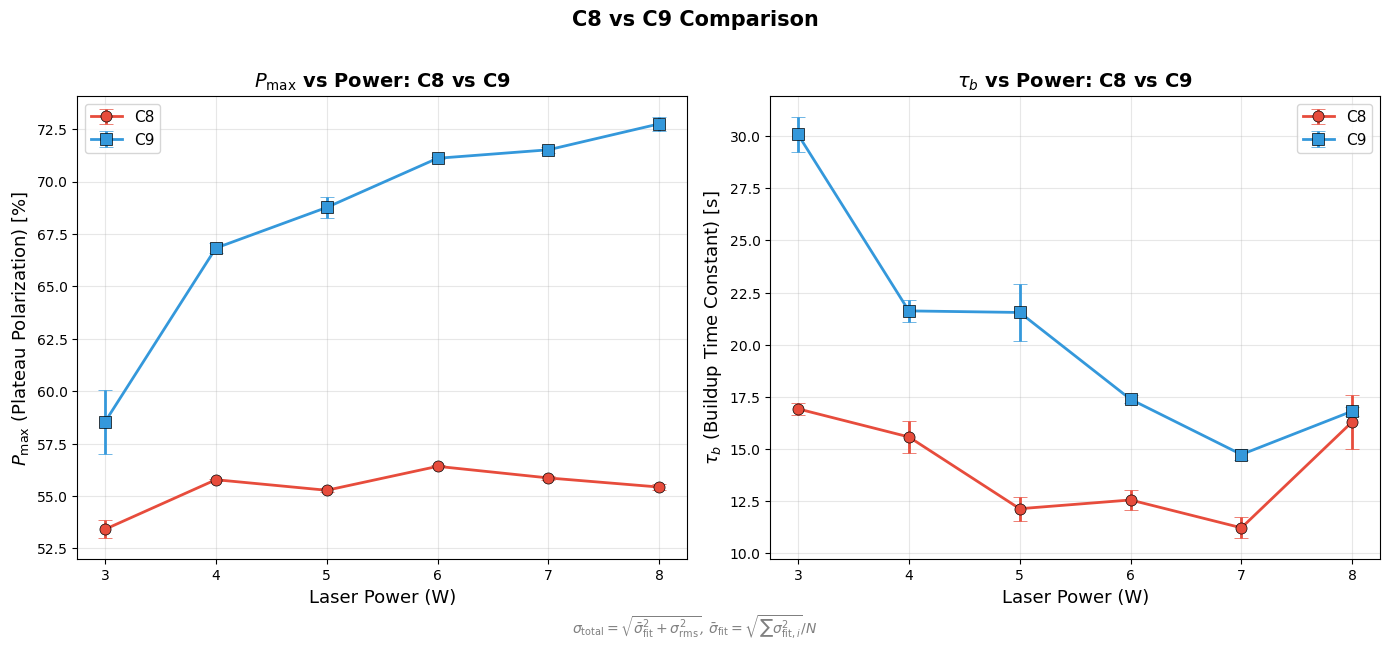

In [12]:
# ============================================================================
# Plot 3: Combined Overlay — P_max and tau_b side by side
# ============================================================================
# σ_total = sqrt( σ_fit_mean² + σ_rms² )

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
dx = 0.0

# --- P_plateau ---
ax1.errorbar(df_C8_avg["power_W"] - dx, df_C8_avg["P_plateau_mean"],
             yerr=df_C8_avg["P_plateau_total"],
             fmt='o-', color='#e74c3c', capsize=5, capthick=1.5, elinewidth=2, linewidth=2,
             markersize=8, markeredgecolor='black', markeredgewidth=0.5, label='C8')
ax1.errorbar(df_C9_avg["power_W"] + dx, df_C9_avg["P_plateau_mean"],
             yerr=df_C9_avg["P_plateau_total"],
             fmt='s-', color='#3498db', capsize=5, capthick=1.5, elinewidth=2, linewidth=2,
             markersize=8, markeredgecolor='black', markeredgewidth=0.5, label='C9')
ax1.set_xlabel("Laser Power (W)", fontsize=13)
ax1.set_ylabel("$P_{\\rm max}$ (Plateau Polarization) [%]", fontsize=13)
ax1.set_title("$P_{\\rm max}$ vs Power: C8 vs C9", fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# --- tau_b ---
ax2.errorbar(df_C8_avg["power_W"] - dx, df_C8_avg["tau_b_mean"],
             yerr=df_C8_avg["tau_b_total"],
             fmt='o-', color='#e74c3c', capsize=5, capthick=1.5, elinewidth=2, linewidth=2,
             markersize=8, markeredgecolor='black', markeredgewidth=0.5, label='C8')
ax2.errorbar(df_C9_avg["power_W"] + dx, df_C9_avg["tau_b_mean"],
             yerr=df_C9_avg["tau_b_total"],
             fmt='s-', color='#3498db', capsize=5, capthick=1.5, elinewidth=2, linewidth=2,
             markersize=8, markeredgecolor='black', markeredgewidth=0.5, label='C9')
ax2.set_xlabel("Laser Power (W)", fontsize=13)
ax2.set_ylabel(r"$\tau_b$ (Buildup Time Constant) [s]", fontsize=13)
ax2.set_title(r"$\tau_b$ vs Power: C8 vs C9", fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

fig.text(0.5, -0.02,
         r"$\sigma_{\rm total}=\sqrt{\bar{\sigma}_{\rm fit}^2+\sigma_{\rm rms}^2}$, "
         r"$\bar{\sigma}_{\rm fit}=\sqrt{\sum\sigma_{{\rm fit},i}^2}/N$",
         ha='center', fontsize=10, style='italic', color='gray')
fig.suptitle("C8 vs C9 Comparison", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("/Users/snip/Documents/MEOP/power_dependence_plots/C8_vs_C9_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# ============================================================================
# Export C8 + C9 summary into one CSV
# Columns: cell, power_W,
#   P_max_mean, P_max_sfit, P_max_srms, P_max_stot,
#   tau_b_mean, tau_b_sfit, tau_b_srms, tau_b_stot,
#   tau_decay_mean, tau_decay_sfit, tau_decay_srms, tau_decay_stot, n
# ============================================================================

_col_select = [
    "power_W",
    "P_plateau_mean",   "P_plateau_fit_mean", "P_plateau_rms",  "P_plateau_total",
    "tau_b_mean",       "tau_b_fit_mean",      "tau_b_rms",      "tau_b_total",
    "tau_mean",         "tau_fit_mean",        "tau_rms",        "tau_total",
    "n",
]
_rename = {
    "P_plateau_mean":      "P_max_mean",
    "P_plateau_fit_mean":  "P_max_sfit",
    "P_plateau_rms":       "P_max_srms",
    "P_plateau_total":     "P_max_stot",
    "tau_b_fit_mean":      "tau_b_sfit",
    "tau_b_rms":           "tau_b_srms",
    "tau_b_total":         "tau_b_stot",
    "tau_mean":            "tau_decay_mean",
    "tau_fit_mean":        "tau_decay_sfit",
    "tau_rms":             "tau_decay_srms",
    "tau_total":           "tau_decay_stot",
}

csv_C8 = df_C8_avg[_col_select].rename(columns=_rename).copy()
csv_C8.insert(0, "cell", "C8")

csv_C9 = df_C9_avg[_col_select].rename(columns=_rename).copy()
csv_C9.insert(0, "cell", "C9")

summary = pd.concat([csv_C8, csv_C9], ignore_index=True).sort_values(["power_W", "cell"])

out_path = "/Users/snip/Documents/MEOP/power_dependence_plots/C8_C9_summary.csv"
summary.to_csv(out_path, index=False, float_format="%.4f")
print(f"Saved: {out_path}\n")
print(summary.to_string(index=False))

Saved: /Users/snip/Documents/MEOP/power_dependence_plots/C8_C9_summary.csv

cell  power_W  P_max_mean  P_max_sfit  P_max_srms  P_max_stot  tau_b_mean  tau_b_sfit  tau_b_srms  tau_b_stot  tau_decay_mean  tau_decay_sfit  tau_decay_srms  tau_decay_stot   n
  C8        3   53.411621    0.027959    0.424266    0.425186   16.923275    0.220285    0.200666    0.297980      109.690486        0.278490        0.484927        0.559205 3.0
  C9        3   58.534767    0.046121    1.509146    1.509850   30.081777    0.181989    0.820116    0.840066      103.034571        0.306196        0.066091        0.313248 3.0
  C8        4   55.777814    0.026812    0.050446    0.057128   15.576155    0.182396    0.759360    0.780958      117.695845        0.337230        0.893857        0.955356 3.0
  C9        4   66.826836    0.050415    0.240638    0.245863   21.621232    0.132760    0.511286    0.528241       98.636834        0.239617        0.588728        0.635623 3.0
  C8        5   55.273722    0.028